# LangChain Practice — Agent + Memory + Tool + Multimodal + Structured Output

This version uses a **hybrid architecture**:

1. **Structured output** for extraction from the fridge image.
2. **Agent + memory + web search tool** for flexible reasoning.
3. **Structured output** again for the final recipe plan.

The key idea: **do not force the whole agent loop into structured output**. Use structure at the boundaries where your app needs reliable data.

## 1. Load environment variables

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 2. Imports

In [2]:
import base64
from typing import Any, Dict, List

from IPython.display import display, Markdown
from ipywidgets import FileUpload
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, SystemMessage
from langchain.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from tavily import TavilyClient

## 3. Define schemas for structured output

Use Pydantic models when you want the LLM response to become reliable Python objects.

In [3]:
class FridgeInventory(BaseModel):
    """Structured result from the fridge image."""

    items: List[str] = Field(
        description="Visible food or drink items in the fridge. Use short common names."
    )
    uncertain_items: List[str] = Field(
        default_factory=list,
        description="Items that may be present but are not visually clear."
    )
    notes: str = Field(
        default="",
        description="Brief visual notes, such as freshness, packaging, or uncertainty."
    )


class RecipePlan(BaseModel):
    """Structured final recipe recommendation."""

    dish_name: str = Field(description="Name of the recommended dish.")
    why_it_fits: str = Field(description="Why this dish fits the fridge ingredients.")
    ingredients_from_fridge: List[str] = Field(
        description="Ingredients from the fridge that will be used."
    )
    extra_ingredients_to_buy: List[str] = Field(
        default_factory=list,
        description="Optional extra ingredients to buy. Keep this minimal."
    )
    steps: List[str] = Field(description="Cooking steps in order.")
    estimated_time_minutes: int = Field(description="Estimated total cooking time in minutes.")
    difficulty: str = Field(description="Easy, medium, or hard.")

## 4. Create the model

Use one base model, then wrap it with `.with_structured_output(...)` only when needed.

In [4]:
model = init_chat_model("gpt-5-nano", model_provider="openai")

inventory_extractor = model.with_structured_output(FridgeInventory)
recipe_formatter = model.with_structured_output(RecipePlan)

## 5. Define the Tavily web search tool

In [5]:
tavily_client = TavilyClient()


@tool
def web_search(query: str) -> Dict[str, Any]:
    """Search the web for cooking ideas, ingredient combinations, or recipe information."""
    return tavily_client.search(query)

# This is the <span style="color: gold;">main agent</span> (orchestrator)

## 6. Create the agent with memory and tool access

The agent stays free-form because it needs to decide whether to search, how to reason, and how to use memory.

In [6]:
checkpointer = InMemorySaver()

agent = create_agent(
    model=model,
    tools=[web_search],
    checkpointer=checkpointer,
)

config = {"configurable": {"thread_id": "fridge-recipe-demo-1"}}

## 7. Upload the fridge image

In [3]:
uploader = FileUpload(accept=".png,.jpg,.jpeg", multiple=False)
display(uploader)

FileUpload(value=(), accept='.png,.jpg,.jpeg', description='Upload')

## 8. Convert uploaded image to base64

In [8]:
if not uploader.value:
    raise ValueError("Please upload one fridge image first, then run this cell again.")

uploaded_file = uploader.value[0]
img_bytes = bytes(uploaded_file["content"])

filename = uploaded_file.get("name", "uploaded_image")
filename_lower = filename.lower()

if filename_lower.endswith(".jpg") or filename_lower.endswith(".jpeg"):
    mime_type = "image/jpeg"
else:
    mime_type = "image/png"

img_b64 = base64.b64encode(img_bytes).decode("utf-8")

print(f"Loaded: {filename}")
print(f"MIME type: {mime_type}")

Loaded: pexels-photo-4443433.png
MIME type: image/png


# We are using <span style="color: gold;">multi-modal message</span> here

## 9. Stage 1 — Structured extraction from the image

This is a good place for structured output because we want a reusable inventory object.

In [10]:
from pprint import pprint

inventory_prompt = HumanMessage(
    content=[
        {
            "type": "text",
            "text": (
                "Look at this fridge image and extract the visible food/drink items. "
                "Return only the structured inventory. Do not invent items you cannot see."
            ),
        },
        {"type": "image", "base64": img_b64, "mime_type": mime_type},
    ]
)

inventory: FridgeInventory = inventory_extractor.invoke([inventory_prompt])
pprint(inventory)

FridgeInventory(items=['olive oil', 'cucumber', 'celery', 'green apple', 'strawberries', 'beet', 'red juice bottle', 'carrots', 'orange juice bottle', 'orange (whole)', 'orange (half)'], uncertain_items=['lemon/lime half', 'greens with red stems (beet greens / Swiss chard)'], notes='Top shelf: olive oil, cucumber, celery, green apple, and a citrus half of unclear type. Middle shelf: greens with red stems (unclear exact type), strawberries, beet, and red juice bottle. Bottom shelf: carrots, orange juice bottle, whole orange, and halved orange.')


## 10. Put the inventory into <span style="color: gold;">main agent memory</span>

The agent does not automatically know the result from the structured extraction call, so we explicitly tell it to remember the inventory.

In [11]:
memory_message = HumanMessage(
    content=(
        "Remember this fridge inventory for our conversation."
        f"Visible items: {inventory.items}"
        f"Uncertain items: {inventory.uncertain_items}"
        f"Notes: {inventory.notes}"
    )
)

memory_response = agent.invoke({"messages": [memory_message]}, config)
print(memory_response["messages"][-1].content)

Got it. I’ll treat this as your current fridge inventory for our chat and use it as the reference moving forward.

Inventory snapshot
- Visible items:
  - Olive oil
  - Cucumber
  - Celery
  - Green apple
  - Strawberries
  - Beet
  - Red juice bottle
  - Carrots
  - Orange juice bottle
  - Orange (whole)
  - Orange (half)
- Uncertain items:
  - Lemon/lime half
  - Greens with red stems (beet greens / Swiss chard)
- Notes:
  - Top shelf: olive oil, cucumber, celery, green apple, and a citrus half of unclear type.
  - Middle shelf: greens with red stems (unclear exact type), strawberries, beet, and red juice bottle.
  - Bottom shelf: carrots, orange juice bottle, whole orange, and halved orange.

What would you like me to do next?
- Keep the identifications as “unclear” for now, and use them as flexible labels.
- Try to confirm or choose likely identifications for the uncertain items.
- Propose recipe ideas that use items you have.
- Track changes if you add or remove items.

Here are s

## 11. Test memory

In [12]:
memory_test = HumanMessage(
    content="What ingredients did I have in the fridge image? Please answer from memory."
)

memory_test_response = agent.invoke({"messages": [memory_test]}, config)
print(memory_test_response["messages"][-1].content)

From memory, your fridge ingredients are:

Visible items:
- Olive oil
- Cucumber
- Celery
- Green apple
- Strawberries
- Beet
- Red juice bottle
- Carrots
- Orange juice bottle
- Orange (whole)
- Orange (half)

Uncertain items:
- Lemon/lime half
- Greens with red stems (beet greens / Swiss chard)

Notes (shelf layout you described):
- Top shelf: olive oil, cucumber, celery, green apple, and a citrus half
- Middle shelf: greens with red stems, strawberries, beet, red juice bottle
- Bottom shelf: carrots, orange juice bottle, whole orange, halved orange


## 12. Stage 2 — Agent uses memory + web search to brainstorm

This is intentionally free-form. The agent can search and reason naturally.

In [13]:
brainstorm_question = HumanMessage(
    content=(
        "Use the web_search tool if useful. Based on the fridge ingredients you remember, "
        "suggest one practical dish I can make. Focus on something simple and realistic."
    )
)

brainstorm_response = agent.invoke({"messages": [brainstorm_question]}, config)
brainstorm_text = brainstorm_response["messages"][-1].content

print(brainstorm_text)

Dish suggestion: Crunchy Cucumber-Celery-Apple Salad with Olive Oil & Orange Dressing

Why this works here:
- Uses: cucumber, celery, green apple, olive oil, and orange (juice from the orange half or the orange juice bottle).
- Quick, fresh, requires no cooking.

Ingredients (serves 1–2):
- 1 small cucumber, thinly sliced
- 2 celery stalks, thinly sliced
- 1 green apple, julienned or thinly sliced
- 1–2 tablespoons olive oil
- 1–2 tablespoons orange juice (from the orange half or the orange juice bottle)
- Salt and pepper to taste

Optional: a few strawberry slices on top for color (not required).

Method:
1) Prep vegetables and fruit: slice cucumber and celery, julienne apple.
2) Make the dressing: whisk olive oil with orange juice, salt, and pepper.
3) Toss everything in a bowl with the dressing until evenly coated.
4) Serve immediately.

Time: about 10 minutes. Simple, crunchy, and uses mostly items you have. If you’d prefer, I can tailor a version to include beets or strawberries a

### What is `model_dump()`?

`model_dump()` is a Pydantic v2 method that converts a model instance into a plain Python dictionary.

```python
class FridgeInventory(BaseModel):
    items: list[str]
    notes: str

inv = FridgeInventory(items=['apple', 'carrot'], notes='fresh')
inv.model_dump()
# {'items': ['apple', 'carrot'], 'notes': 'fresh'}
```

We use it here to serialize the `FridgeInventory` object into a dict before embedding it in the prompt string — because you can't directly interpolate a Pydantic object into an f-string in a meaningful way.

Useful options:
- `exclude_none=True` — drops fields that are `None`
- `exclude_unset=True` — drops fields that were never explicitly set
- `mode='json'` — ensures all values are JSON-serializable (e.g. `datetime` → string)

## 13. Stage 3 — Convert the final answer into structured output

Now that the agent has done the flexible work, we ask the model to format the final plan into a reliable schema.

In [14]:
recipe_prompt = HumanMessage(
    content=(
        "Convert the following recipe recommendation into the RecipePlan schema."
        "Important rules:"
        "- Use the fridge inventory as the source of truth."
        "- Do not add many extra ingredients."
        "- Keep the steps beginner-friendly."
        f"Fridge inventory: {inventory.model_dump()}"
        f"Agent recommendation: {brainstorm_text}"
    )
)

recipe_plan: RecipePlan = recipe_formatter.invoke([recipe_prompt])
recipe_plan

RecipePlan(dish_name='Crunchy Cucumber-Celery-Apple Salad with Olive Oil & Orange Dressing', why_it_fits='Uses cucumber, celery, green apple, olive oil, and orange juice from the fridge; quick, fresh, and requires no cooking.', ingredients_from_fridge=['cucumber', 'celery', 'green apple', 'olive oil', 'orange juice (from orange half or orange juice bottle)', 'strawberries (optional garnish)'], extra_ingredients_to_buy=[], steps=['Prepare vegetables and fruit: slice cucumber and celery, and julienne the green apple.', 'Make the dressing: whisk olive oil with orange juice.', 'Toss the cucumber, celery, apple, and optional strawberries with the dressing until evenly coated.', 'Serve immediately.'], estimated_time_minutes=10, difficulty='Easy')

## 14. Display the structured recipe nicely

In [15]:
display(
    Markdown(f"""
# {recipe_plan.dish_name}

**Why it fits:** {recipe_plan.why_it_fits}

**Ingredients from fridge:**  
{", ".join(recipe_plan.ingredients_from_fridge)}

**Extra ingredients to buy:**  
{", ".join(recipe_plan.extra_ingredients_to_buy) if recipe_plan.extra_ingredients_to_buy else "None"}

**Estimated time:** {recipe_plan.estimated_time_minutes} minutes  
**Difficulty:** {recipe_plan.difficulty}

## Steps
""")
)

for i, step in enumerate(recipe_plan.steps, start=1):
    display(Markdown(f"{i}. {step}"))


# Crunchy Cucumber-Celery-Apple Salad with Olive Oil & Orange Dressing

**Why it fits:** Uses cucumber, celery, green apple, olive oil, and orange juice from the fridge; quick, fresh, and requires no cooking.

**Ingredients from fridge:**  
cucumber, celery, green apple, olive oil, orange juice (from orange half or orange juice bottle), strawberries (optional garnish)

**Extra ingredients to buy:**  
None

**Estimated time:** 10 minutes  
**Difficulty:** Easy

## Steps


1. Prepare vegetables and fruit: slice cucumber and celery, and julienne the green apple.

2. Make the dressing: whisk olive oil with orange juice.

3. Toss the cucumber, celery, apple, and optional strawberries with the dressing until evenly coated.

4. Serve immediately.

## 15. Optional: agent-level structured output

LangChain also supports `response_format=` directly in `create_agent`. That can work, but for this exercise I would **not** make the main memory/tool agent structured from the beginning.

Use this only when the agent's final answer must always match one schema.

In [ ]:
# Example only. You do not need this for the main exercise.
#
# structured_recipe_agent = create_agent(
#     model=model,
#     tools=[web_search],
#     checkpointer=InMemorySaver(),
#     response_format=RecipePlan,
# )
#
# result = structured_recipe_agent.invoke(
#     {"messages": [HumanMessage(content="Find a simple recipe using eggs and vegetables.")]},
#     {"configurable": {"thread_id": "structured-agent-demo"}},
# )
#
# result["structured_response"]

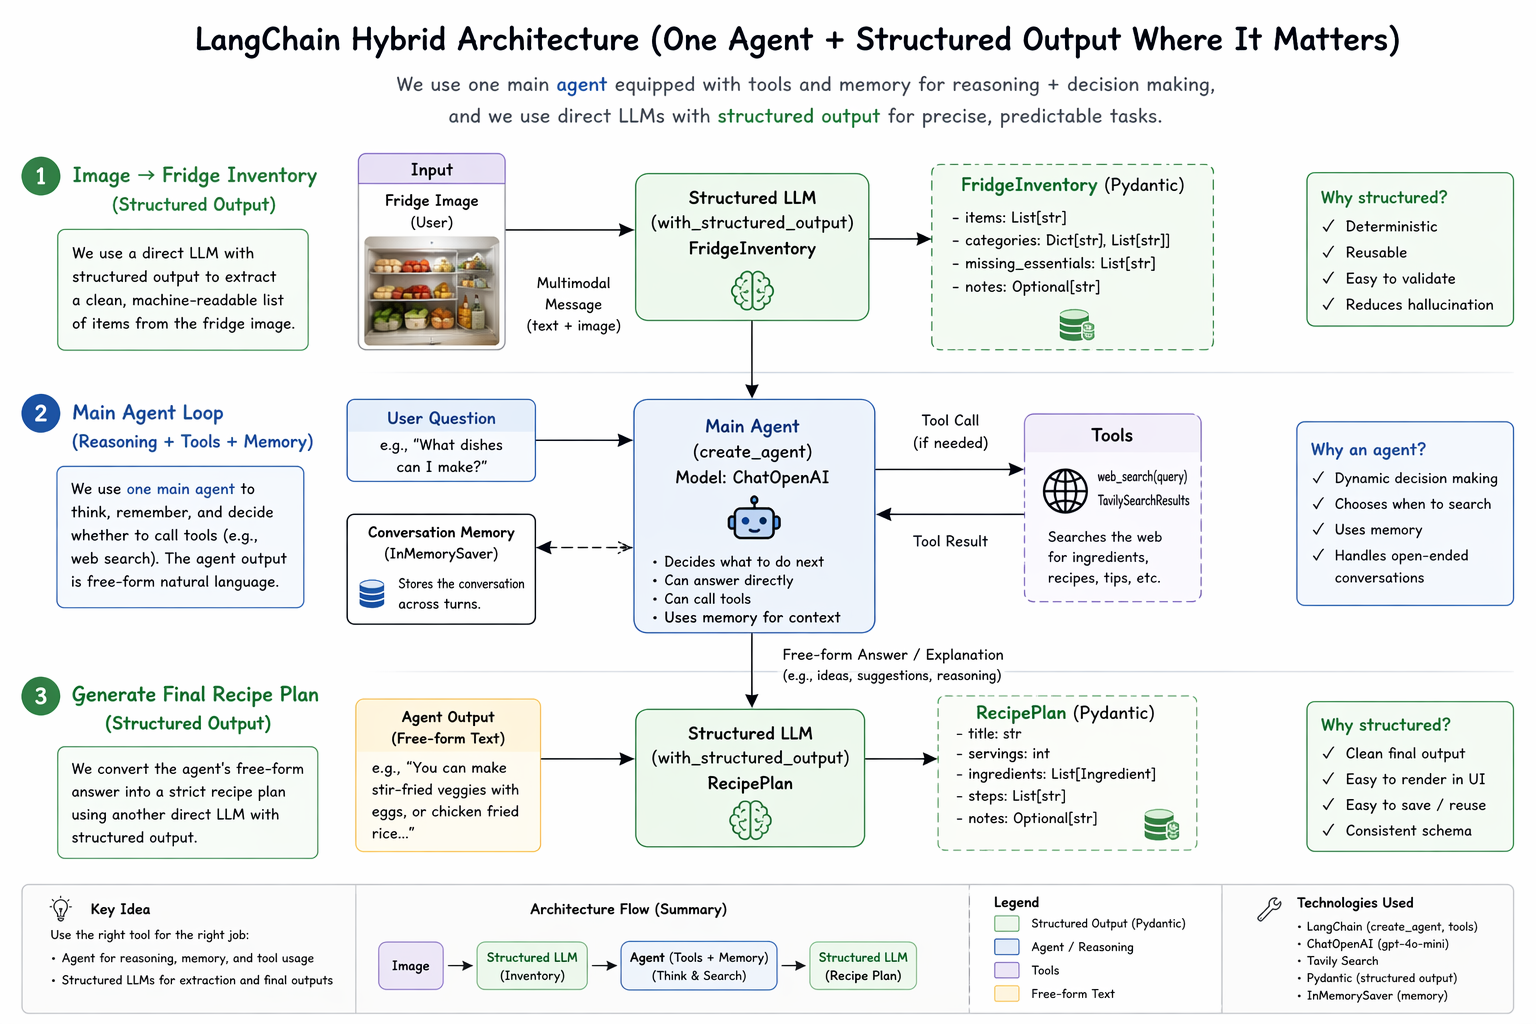

In [5]:
from IPython.display import display, Image

display(Image(filename='./resources/1.4.5.5.png'))